In [51]:
import math
import numpy as np
from numpy import linalg as LA
import quantecon as qe
import matplotlib.pyplot as plt
import pandas as pd

import random
random.seed(1234)

### part e

In [163]:
a = 0.99

p = [[1-a, a, 0],   # probability transition matrix
     [a, 0, 1-a],
     [0, 1-a, a]]

steps = np.int64(500)     # steps in MC

x_0 = 1     # starting state

num_simulations = np.int64(1E5)

# generate a Markov Chain from probability transition matrix p
mc = qe.MarkovChain(p, state_values = (1, 2, 3))

mc_lst = []     # store the markov chains

# simulate N MCs for [steps] steps
for i in range(0, num_simulations):
    # simluate Markov-chain for [steps] steps
    x_mc = mc.simulate(ts_length = steps, init = x_0)
    mc_lst.append(x_mc)

# store chains in dataframe for easier computations
mc_df = pd.DataFrame(mc_lst)

In [164]:
studied_state = 1   # state we wish to study

# fraction chains in studied_state at time n, will be plotted
# should be len(state_frac_at_n) = steps with 
state_frac_at_n = [mc_df[col].value_counts()[studied_state] / len(mc_df) for col in mc_df.columns] # 

# ensure fraction computed for each time step in chain
# ensure 100% initialized in correct starting state
if (len(state_frac_at_n) != steps) or (state_frac_at_n[0] != 1):
    print("Error.")



In [154]:
state_frac_at_n[-10]*1E5
print(state_frac_at_n[0], state_frac_at_n[-1])
print(state_frac_at_n[1], state_frac_at_n[-2])
print(state_frac_at_n[5], state_frac_at_n[-6])

1.0 0.17604
0.00931 0.65753
0.02836 0.67882


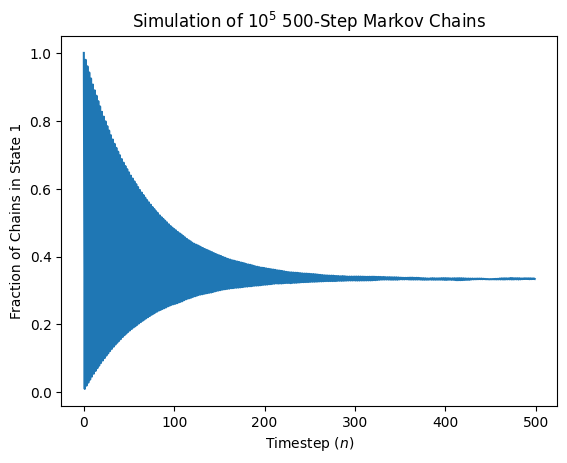

In [165]:
# plot results for all MCs
plt.plot(state_frac_at_n)
plt.title(f"Simulation of $10^5$ {steps}-Step Markov Chains")
plt.xlabel("Timestep ($n$)")
plt.ylabel(f"Fraction of Chains in State {studied_state}")
plt.show()

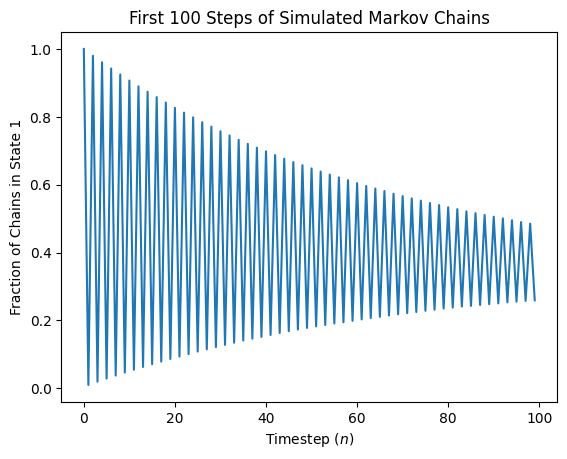

In [169]:
max = 100
# plot results first 100 MCs
plt.plot(state_frac_at_n[0:max])
plt.title(f"First {max} Steps of Simulated Markov Chains")
plt.xlabel("Timestep ($n$)")
plt.ylabel(f"Fraction of Chains in State {studied_state}")
plt.show()